# ANALYSIS

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
from pathlib import Path

## Extract Akantu simulations

In [2]:
BASE_DIR = Path('/scratch/saporito/Frag3D')
FINAL_STEP = 'step_36533'
MASS_THRESHOLD = 1e-6
DENSITY = 2203.0  # kg/m^3

SIM_FOLDERS = [
    'sim_vel1.0e+03_sf4.0e-01_T4.0e-05_k2.0e-01_sh_gaussian_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_0.0e+00_0.0e+00',
    'sim_vel1.0e+04_sf4.0e-01_T4.0e-05_k2.0e-01_sh_gaussian_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_0.0e+00_0.0e+00',
    'sim_vel1.5e+03_sf4.0e-01_T4.0e-05_k2.0e-01_sh_gaussian_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_0.0e+00_0.0e+00',
    'sim_vel1.7e+03_sf4.0e-01_T4.0e-05_k2.0e-01_sh_gaussian_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_0.0e+00_0.0e+00'
]

def make_label(folder: str) -> str:
    m_vel  = re.search(r'vel([^_]+)', folder)
    m_k    = re.search(r'_k([^_]+)', folder)
    m_sh   = re.search(r'sh_([a-zA-Z]+)', folder)
    
    m_thxy = re.search(r'thxy([^_]+)', folder)
    m_thz  = re.search(r'thz([^_]+)',  folder)
    m_cntr = re.search(r'cntr_([0-9.e+\-]+)_([0-9.e+\-]+)', folder)
    
    vel  = float(m_vel.group(1)) if m_vel else 0.0
    k    = float(m_k.group(1)) if m_k else 0.0
    sh   = m_sh.group(1) if m_sh else 'unknown'
    
    thxy   = float(m_thxy.group(1)) if m_thxy else 0
    thz    = float(m_thz.group(1))  if m_thz  else 0
    cx, cy = (float(m_cntr.group(1)), float(m_cntr.group(2))) if m_cntr else (0, 0)
    
    return f'vel={vel:.1e} k={k:.2f} sh={sh} | thxy={thxy:.0f}° thz={thz:.0f}° | cntr=({cx:.2g},{cy:.2g})'

LABELS = [make_label(f) for f in SIM_FOLDERS]
COLORS = plt.cm.tab10(np.linspace(0, 0.5, len(SIM_FOLDERS)))

print('Simulation labels:')
for i, lbl in enumerate(LABELS):
    print(f'  [{i}] {lbl}')

Simulation labels:
  [0] vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0,0)
  [1] vel=1.0e+04 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0,0)
  [2] vel=1.5e+03 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0,0)
  [3] vel=1.7e+03 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0,0)


## Extract SBM simulations

In [3]:
SBM_DIR = Path('/home/saporito/NASA-breakup-model-cpp/AkantuComparison/')

SBM_FOLDERS = [
    'v10000',
    'v1500',
    'v1700',
    'v1000'
]


def parse_velocity_vector(v_str):
    """
    Convert string:
    '[4.523031151046023 -226.04863147567926 -145.7030932365865]'
    -> np.array([x,y,z])
    """
    if pd.isna(v_str): return np.zeros(3)
    vals = np.fromstring(v_str.strip('[]'), sep=' ')

    if len(vals) != 3:
        raise ValueError(f'Cannot parse velocity vector: {v_str}')

    return vals
def load_single_sbm_csv(file: Path) -> dict:
    """Load a single SBM result CSV file"""
    if not file.exists():
        print(f'WARNING: Missing SBM file {file}')
        return None
    
    df = pd.read_csv(file)
    
    # Keep only target fragments
    df = df[df['Name'] == 'Target-Collision-Fragment'].copy()
    
    # Mass threshold
    df = df[df['Mass [kg]'] > MASS_THRESHOLD].copy()
    
    n_fragments = len(df)
    
    if n_fragments == 0:
        return {
            'mass': np.array([]), 'volume': np.array([]), 'vmag': np.array([]),
            'vx': np.array([]), 'vy': np.array([]), 'vz': np.array([]),
            'ke': np.array([]), 'length': np.array([]), 'area_mass': np.array([]),
            'area': np.array([]), 'n_fragments': 0
        }
    
    vel_vectors = np.vstack(df['Velocity [m/s]'].apply(parse_velocity_vector).to_numpy())
    
    vx = vel_vectors[:, 0]
    vy = vel_vectors[:, 1]
    vz = vel_vectors[:, 2]
    vmag = np.linalg.norm(vel_vectors, axis=1)
    
    mass = df['Mass [kg]'].to_numpy()
    kinetic_energy = 0.5 * mass * vmag**2
    characteristic_length = df['Characteristic Length [m]'].to_numpy()
    area = df['Area [m^2]'].to_numpy()
    volume = area * characteristic_length
    
    return {
        'mass': mass,
        'volume': volume,
        'vmag': vmag,
        'vx': vx,
        'vy': vy,
        'vz': vz,
        'ke': kinetic_energy,
        'length': characteristic_length,
        'area_mass': df['A/M [m^2/kg]'].to_numpy(),
        'area': area,
        'n_fragments': n_fragments
    }

def aggregate_sbm_runs(folder: str, suffix: str, runs: list = range(1, 11)) -> dict:
    """
    Load multiple CSV files for a specific configuration suffix ('MC' or 'noMC').
    Averages fragment distributions by aligning and interpolating them to the 
    mean fragment count, preserving the original dictionary structure.
    """
    base_path = SBM_DIR / folder / f'input-output-{suffix}'
    all_data = []
    
    for run in runs:
        csv_file = base_path / f'result{run}.csv'
        data = load_single_sbm_csv(csv_file)
        if data is not None and data['n_fragments'] > 0:
            all_data.append(data)
            
    if len(all_data) == 0:
        print(f'WARNING: No data found for {folder} [{suffix}]')
        return None

    # Calculate the target average length for the arrays
    lengths = [d['n_fragments'] for d in all_data]
    target_len = int(np.round(np.mean(lengths)))
    
    # Base structure matching your original design requirements
    result = {
        'n_fragments': target_len,
        'n_fragments_std': np.std(lengths),
        'n_runs': len(all_data),
        'individual_runs': all_data
    }
    
    # Target keys that contain arrays needing averaging
    array_keys = ['mass', 'volume', 'vmag', 'vx', 'vy', 'vz', 'ke', 'length', 'area_mass', 'area']
    
    # Create a unified grid to interpolate onto
    common_grid = np.linspace(0, 1, target_len)
    
    for key in array_keys:
        interp_runs = []
        for d in all_data:
            # Sort the individual run array to align distributions (CDF matching)
            sorted_arr = np.sort(d[key])
            current_grid = np.linspace(0, 1, len(sorted_arr))
            
            # Map the run data cleanly onto the average-sized grid
            interp_arr = np.interp(common_grid, current_grid, sorted_arr)
            interp_runs.append(interp_arr)
        
            # Create a unified grid to interpolate onto
            common_grid = np.linspace(0, 1, target_len)

            # Initialize lists to hold the interpolated runs for each key
            interp_results = {key: [] for key in array_keys}

            for d in all_data:
                # 1. Get the sorting indices based on MASS only
                sort_idx = np.argsort(d['mass'])
                current_grid = np.linspace(0, 1, len(sort_idx))
                
                # 2. Sort EVERY key using that identical mass-based index
                for key in array_keys:
                    sorted_arr = d[key][sort_idx]
                    
                    # 3. Interpolate the mass-aligned data onto the common grid
                    interp_arr = np.interp(common_grid, current_grid, sorted_arr)
                    interp_results[key].append(interp_arr)

            # 4. Take the mathematical average across the aligned runs
            for key in array_keys:
                result[key] = np.mean(interp_results[key], axis=0)
        
    return result

# --- Main Data Loading Loop ---
sbm_fragment_data = {}

for folder in SBM_FOLDERS:
    for suffix in ['MC']:
        config_key = f'{folder} [{suffix}]'
        
        # Extract the averaged results directly into your original dictionary structure
        averaged_data = aggregate_sbm_runs(folder, suffix)
        
        if averaged_data is not None:
            sbm_fragment_data[config_key] = averaged_data

print(f'Successfully loaded {len(sbm_fragment_data)} SBM configurations.')

Successfully loaded 4 SBM configurations.


## Load final-step data for all Akantu simulations

In [4]:
SCALAR_ATTRS = ['econ', 'edis', 'ekin', 'epot', 'erev', 'nb_fragments', 'total_energy', 'work']

scalar_rows = []
fragment_data = {}

for folder, label in zip(SIM_FOLDERS, LABELS):
    h5path = BASE_DIR / folder / 'data.h5'
    with h5py.File(h5path, 'r') as f:
        step = f[FINAL_STEP]

        row = {'sim': label}
        for attr in SCALAR_ATTRS:
            row[attr] = float(step.attrs[attr])
        masses = step['fragment_mass'][:]
        vels   = step['fragment_velocity'][:]

        row['nb_fragments_heavy'] = int((masses >= MASS_THRESHOLD).sum())
        scalar_rows.append(row)

        vmag = np.linalg.norm(vels, axis=1)
        fragment_data[label] = {

        'mass': masses,

        'volume': (
            masses / DENSITY
        ),

        'vmag': vmag,
        'vx': vels[:, 0],
        'vy': vels[:, 1],
        'vz': vels[:, 2],
    }

print('Done loading', len(scalar_rows), 'simulations.')

Done loading 4 simulations.


## Select simulations to keep

In [5]:
AKANTU_SELECTION = [
    LABELS[0],
    LABELS[1],
    LABELS[2],
    LABELS[3]
]

SBM_SELECTION_MC = [
    'v10000 [MC]',
    'v1500 [MC]',
    'v1700 [MC]',
    'v1000 [MC]'
]

SBM_SELECTION_NOMC = [

]

COMPARISON_COLORS = {
    'akantu': plt.cm.Blues,
    'sbm': plt.cm.Reds,
}

## Fragment statistics table  
mean / max / min / std of mass, |v|, vx, vy, vz, volume, number of fragments, kinetic energy

In [6]:
def filter_fragment_data(fragment_data, mass_threshold):
    filtered_data = {}

    for label, fd in fragment_data.items():

        mask = fd['mass'] > mass_threshold

        filtered_data[label] = {
            key: values[mask]
            for key, values in fd.items()
        }

    return filtered_data

fragment_data = filter_fragment_data(
    fragment_data,
    MASS_THRESHOLD
)

In [7]:
STAT_FUNCS = {
    'mean': np.mean,
    'min': np.min,
    'max': np.max,
    'std': np.std
}

FRAG_KEYS = [
    'mass',
    'volume',
    'vmag',
    'vx',
    'vy',
    'vz'
]

FRAG_LABELS = [
    'Mass',
    'Volume',
    '|v|',
    'vx',
    'vy',
    'vz'
]
df_scalar = pd.DataFrame(scalar_rows).set_index('sim')


rows = []
for sim_label in AKANTU_SELECTION:

    if sim_label not in fragment_data:
        continue

    row = {'dataset': sim_label,'type': 'Akantu'}

    scalar_row = df_scalar.loc[sim_label]

    row['E_con'] = scalar_row['econ']
    row['E_dis'] = scalar_row['edis']
    row['E_kin'] = scalar_row['ekin']
    row['E_pot'] = scalar_row['epot']
    row['E_rev'] = scalar_row['erev']
    row['E_tot'] = scalar_row['total_energy']
    row['Work'] = scalar_row['work']

    row['N_fragments'] = int(scalar_row['nb_fragments_heavy'])

    fd = fragment_data[sim_label]

    for key, label in zip(FRAG_KEYS,FRAG_LABELS):

        arr = fd[key]

        if len(arr) == 0:
            row[f'{label}_mean'] = np.nan
            row[f'{label}_min'] = np.nan
            row[f'{label}_max'] = np.nan
            row[f'{label}_std'] = np.nan

        else:
            row[f'{label}_mean'] = np.mean(arr)
            row[f'{label}_min'] = np.min(arr)
            row[f'{label}_max'] = np.max(arr)
            row[f'{label}_std'] = np.std(arr)

    rows.append(row)

for dataset in (SBM_SELECTION_MC + SBM_SELECTION_NOMC):

    if dataset not in sbm_fragment_data:
        print(f'Skipping {dataset}')
        continue

    fd = sbm_fragment_data[dataset]

    if fd is None:
        continue

    row = {
        'dataset': dataset,
        'type': 'SBM'
    }

    row['E_con'] = np.nan
    row['E_dis'] = np.nan
    row['E_kin'] = fd['ke'].sum() if 'ke' in fd else np.nan
    row['E_pot'] = np.nan
    row['E_rev'] = np.nan
    row['E_tot'] = np.nan
    row['Work'] = np.nan

    row['N_fragments'] = (
        fd['n_fragments']
    )

    for key, label in zip(
        FRAG_KEYS,
        FRAG_LABELS
    ):

        arr = fd[key]

        if len(arr) == 0:

            row[f'{label}_mean'] = np.nan
            row[f'{label}_min'] = np.nan
            row[f'{label}_max'] = np.nan
            row[f'{label}_std'] = np.nan

        else:

            row[f'{label}_mean'] = np.mean(arr)
            row[f'{label}_min'] = np.min(arr)
            row[f'{label}_max'] = np.max(arr)
            row[f'{label}_std'] = np.std(arr)

    rows.append(row)
df_results = pd.DataFrame(rows)

df_results = df_results.set_index(
    ['type', 'dataset']
)

pd.set_option(
    'display.float_format',
    '{:.4e}'.format
)

pd.set_option(
    'display.max_columns',
    None
)

display(df_results)

E_con  \
type   dataset                                                         
Akantu vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0°... 0.0000e+00   
       vel=1.0e+04 k=0.20 sh=gaussian | thxy=0° thz=0°... 0.0000e+00   
       vel=1.5e+03 k=0.20 sh=gaussian | thxy=0° thz=0°... 0.0000e+00   
       vel=1.7e+03 k=0.20 sh=gaussian | thxy=0° thz=0°... 0.0000e+00   
SBM    v10000 [MC]                                               NaN   
       v1500 [MC]                                                NaN   
       v1700 [MC]                                                NaN   
       v1000 [MC]                                                NaN   

                                                               E_dis  \
type   dataset                                                         
Akantu vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0°... 9.3832e-02   
       vel=1.0e+04 k=0.20 sh=gaussian | thxy=0° thz=0°... 1.5887e-01   
       vel=1.5e+03 k=0.20 sh=gaussian | thxy=0° thz=0°... 1.0595e-01   
       vel=1.7e+03 k=0.20 sh=gaussian | thxy=0° thz=0°... 1.0910e-01   
SBM    v10000 [MC]                                               NaN   
       v1500 [MC]                                                NaN   
       v1700 [MC]                                                NaN   
       v1000 [MC]                                                NaN   

                                                               E_kin  \
type   dataset                                                         
Akantu vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0°... 8.6589e+01   
       vel=1.0e+04 k=0.20 sh=gaussian | thxy=0° thz=0°... 8.6503e+03   
       vel=1.5e+03 k=0.20 sh=gaussian | thxy=0° thz=0°... 1.9471e+02   
       vel=1.7e+03 k=0.20 sh=gaussian | thxy=0° thz=0°... 2.5006e+02   
SBM    v10000 [MC]                                        1.5879e+03   
       v1500 [MC]                                         1.3380e+02   
       v1700 [MC]                                         2.0277e+02   
       v1000 [MC]                                         6.5366e+01   

                                                               E_pot  \
type   dataset                                                         
Akantu vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0°... 2.1341e-01   
       vel=1.0e+04 k=0.20 sh=gaussian | thxy=0° thz=0°... 1.1013e+00   
       vel=1.5e+03 k=0.20 sh=gaussian | thxy=0° thz=0°... 2.4113e-01   
       vel=1.7e+03 k=0.20 sh=gaussian | thxy=0° thz=0°... 2.4601e-01   
SBM    v10000 [MC]                                               NaN   
       v1500 [MC]                                                NaN   
       v1700 [MC]                                                NaN   
       v1000 [MC]                                                NaN   

                                                               E_rev  \
type   dataset                                                         
Akantu vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0°... 2.1437e-04   
       vel=1.0e+04 k=0.20 sh=gaussian | thxy=0° thz=0°... 2.2164e-04   
       vel=1.5e+03 k=0.20 sh=gaussian | thxy=0° thz=0°... 2.1390e-04   
       vel=1.7e+03 k=0.20 sh=gaussian | thxy=0° thz=0°... 2.2616e-04   
SBM    v10000 [MC]                                               NaN   
       v1500 [MC]                                                NaN   
       v1700 [MC]                                                NaN   
       v1000 [MC]                                                NaN   

                                                               E_tot  \
type   dataset                                                         
Akantu vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0°... 8.6896e+01   
       vel=1.0e+04 k=0.20 sh=gaussian | thxy=0° thz=0°... 8.6515e+03   
       vel=1.5e+03 k=0.20 sh=gaussian | thxy=0° thz=0°... 1.9505e+02   
       vel=1.7e+03 k=0.20 sh=gaussian | thxy=0° thz=0°... 2.5042e+02   
SBM    v10000 [MC]        

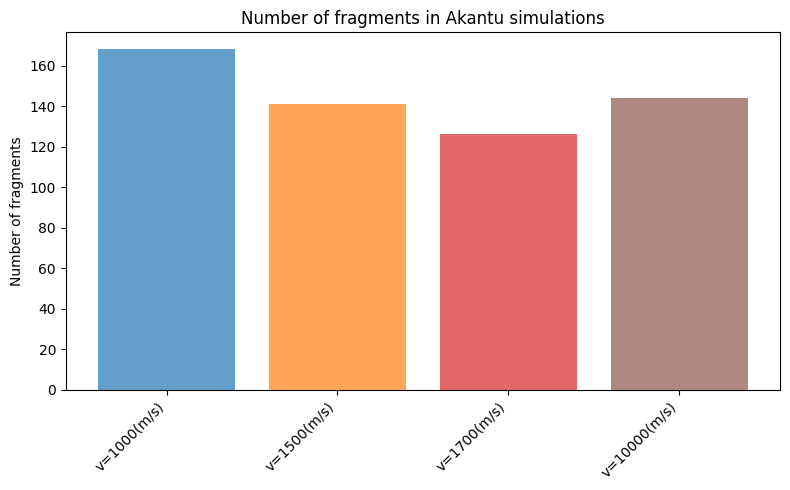

In [8]:
# plot for the n_fragments of the 4 akantu simulations
y = df_results.loc['Akantu', 'N_fragments']
x = np.arange(len(y))
plt.figure(figsize=(8, 5))
plt.bar(x, y, color=COLORS[:len(y)], alpha=0.7)
plt.xticks(x, ["v=1000(m/s)", "v=1500(m/s)", "v=1700(m/s)", "v=10000(m/s)"], rotation=45, ha='right')
plt.ylabel('Number of fragments')
plt.title('Number of fragments in Akantu simulations')
plt.tight_layout()
plt.show()

## Distribution plots functions

In [9]:
from scipy.stats import gaussian_kde

def kde_line(ax, arr, color, label, log_x=False, bw_method='scott'):
    data = arr[arr > 0] if log_x else arr
    if len(data) < 2:
        return
    try:
        if log_x:
            log_data = np.log10(data)
            if np.ptp(log_data) == 0:
                return
            kde = gaussian_kde(log_data, bw_method=bw_method)
            xs_log = np.linspace(log_data.min(), log_data.max(), 500)
            ys = kde(xs_log) / np.log(10)
            xs = 10 ** xs_log
        else:
            if np.ptp(data) == 0:
                return
            kde = gaussian_kde(data, bw_method=bw_method)
            xs = np.linspace(data.min(), data.max(), 500)
            ys = kde(xs)
        ax.plot(xs, ys, color=color, label=label, linewidth=1.8)
        ax.fill_between(xs, ys, alpha=0.12, color=color)
    except Exception:
        return


def plot_kde_combined(frag_data, labels, colors, key, xlabel, log_x=False):
    fig, ax = plt.subplots(figsize=(9, 4))
    for label, color in zip(labels, colors):
        if label in frag_data:
            kde_line(ax, frag_data[label][key], color, label, log_x)
            
    if log_x:
        ax.set_xscale('log')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Probability density', fontsize=11)
    ax.set_title(f'Distribution of {xlabel} - all configs', fontsize=12)
    
    handles, legend_labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(fontsize=7, framealpha=0.5)
        
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2e'))
    plt.tight_layout()
    plt.show()


def plot_kde_individual(frag_data, labels, colors, key, xlabel, log_x=False):
    valid_mins = []
    valid_maxs = []
    
    for lbl in labels:
        if lbl in frag_data:
            arr = frag_data[lbl][key]
            data = arr[arr > 0] if log_x else arr
            if len(data) >= 2 and np.ptp(data) > 0:
                valid_mins.append(data.min())
                valid_maxs.append(data.max())
                
    if not valid_mins:
        print(f"Skipping individual plots for {xlabel}: Not enough valid data points.")
        return
        
    xmin, xmax = min(valid_mins), max(valid_maxs)
    
    for label, color in zip(labels, colors):
        if label not in frag_data:
            continue
            
        arr = frag_data[label][key]
        data = arr[arr > 0] if log_x else arr
        if len(data) < 2:
            continue
            
        fig, ax = plt.subplots(figsize=(5, 4))
        kde_line(ax, frag_data[label][key], color, label=None, log_x=log_x)
        
        if log_x:
            ax.set_xscale('log')
        ax.set_xlim(xmin, xmax)
        ax.set_title(label, fontsize=8, wrap=True)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel('Probability density', fontsize=10)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2e'))
        plt.tight_layout()
        plt.show()

## Scatter plot functions

In [10]:
def scatter_vmag_vs_mass(frag_data, labels, colors, title_suffix='', ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 4.5))
        
    for label, color in zip(labels, colors):
        if label in frag_data:
            fd = frag_data[label]
            if len(fd['mass']) == 0: 
                continue
            ax.scatter(fd['mass'], fd['vmag'], s=20, alpha=0.5,
                       color=color, label=label, linewidths=0)
                       
    ax.set_xscale('log')
    ax.set_xlabel('Fragment mass', fontsize=10)
    ax.set_ylabel('Velocity magnitude |v|', fontsize=10)
    ax.set_title(f'|v| vs mass{title_suffix}', fontsize=11)
    
    if standalone:
        handles, legend_labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(fontsize=7, framealpha=0.5)
        plt.tight_layout()
        plt.show()

In [11]:
def plot_kde_akantu_vs_sbm(
    akantu_data,
    sbm_data,
    akantu_selection,
    sbm_selection,
    key,
    xlabel,
    log_x=False,
    figsize=(9, 4)
):

    fig, ax = plt.subplots(figsize=figsize)

    ak_colors = COMPARISON_COLORS['akantu'](np.linspace( 0.4, 0.9, max(len(akantu_selection), 1)))

    for label, color in zip(akantu_selection, ak_colors):

        if label not in akantu_data:
            continue

        kde_line(ax=ax, arr=akantu_data[label][key],color=color,label=f'Akantu | {label}',log_x=log_x)

    sbm_colors = COMPARISON_COLORS['sbm']( np.linspace( 0.4, 0.9, max(len(sbm_selection), 1)))

    for label, color in zip( sbm_selection, sbm_colors ):

        if label not in sbm_data:
            continue

        if sbm_data[label] is None:
            continue

        kde_line(ax=ax,  arr=sbm_data[label][key], color=color, label=f'SBM | {label}', log_x=log_x)

    if log_x:
        ax.set_xscale('log')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Probability density')

    ax.set_title(f'Akantu vs SBM — {xlabel}')

    ax.yaxis.set_major_formatter( ticker.FormatStrFormatter('%.2e'))

    ax.legend( fontsize=8,framealpha=0.6)

    plt.tight_layout()
    plt.show()

## Plots

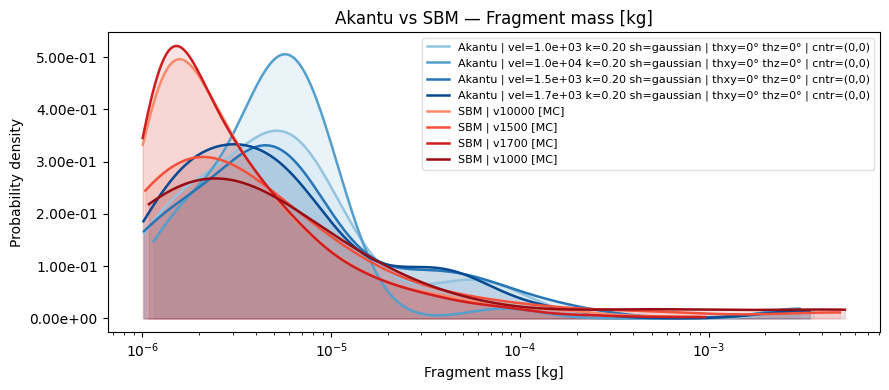

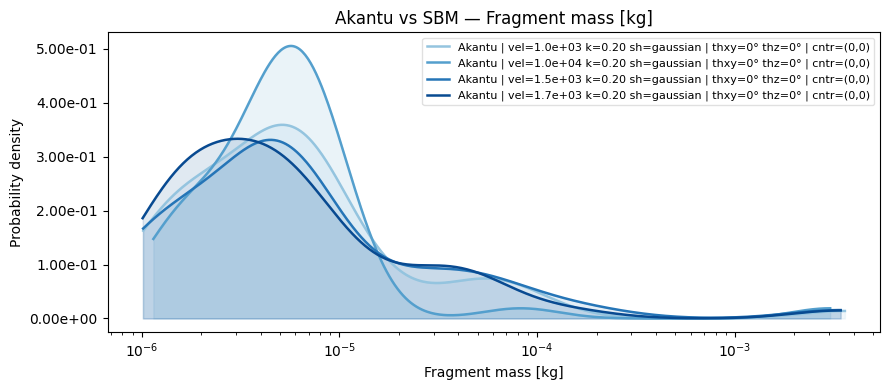

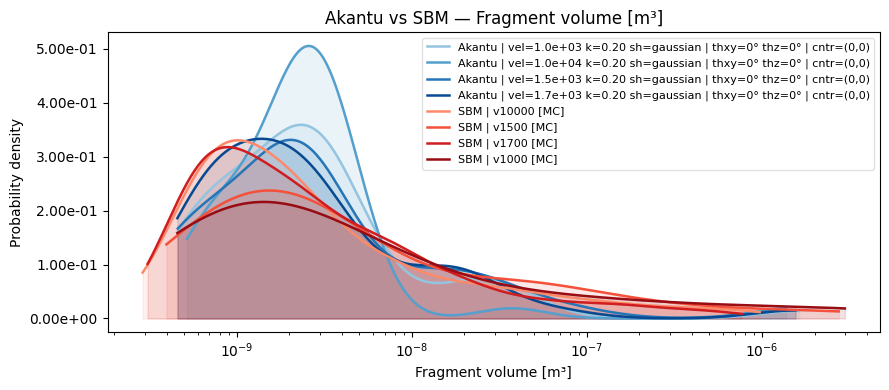

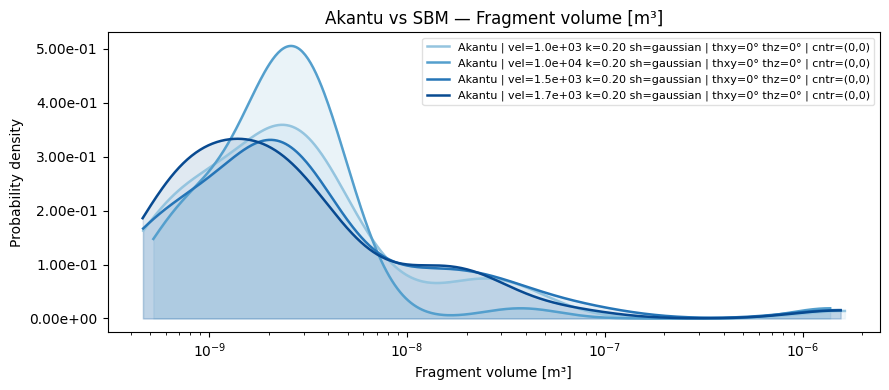

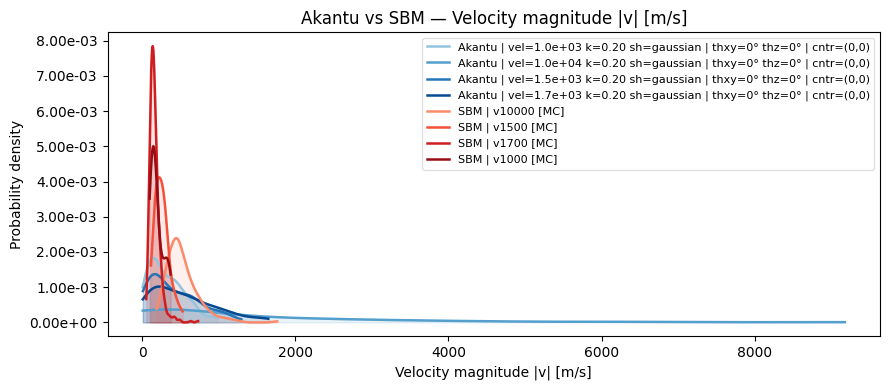

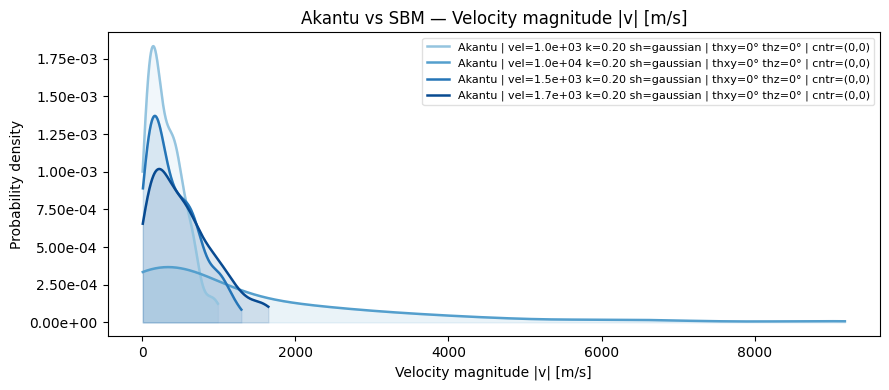

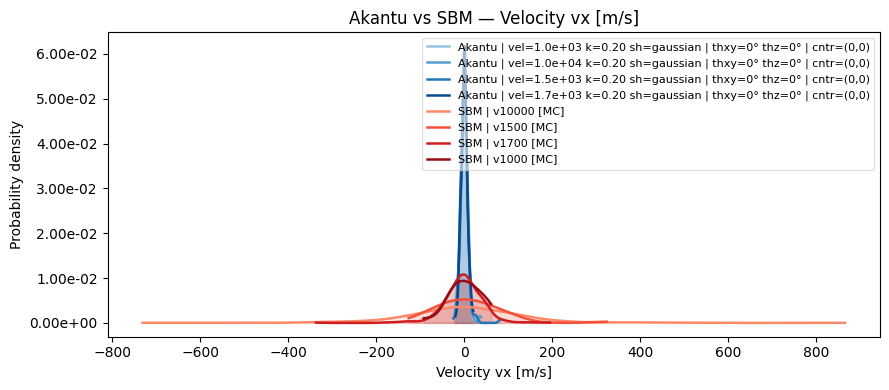

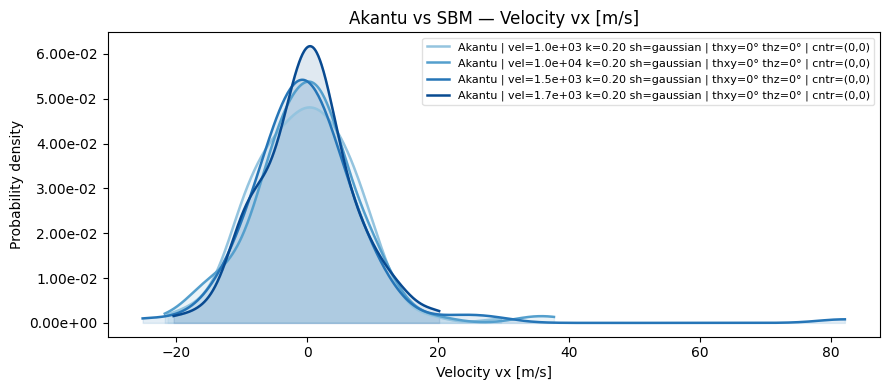

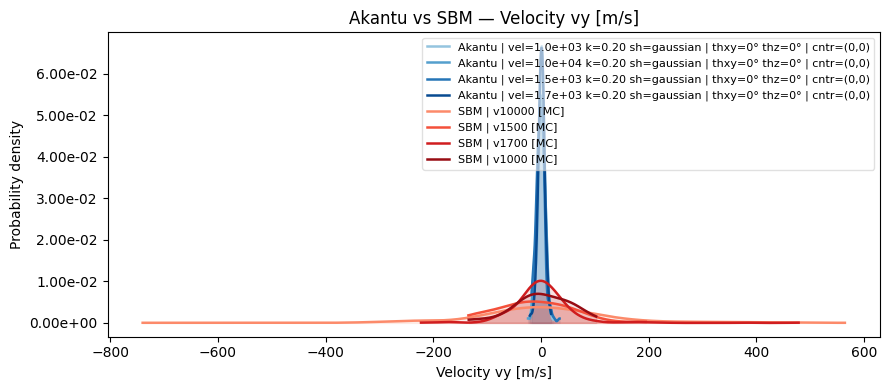

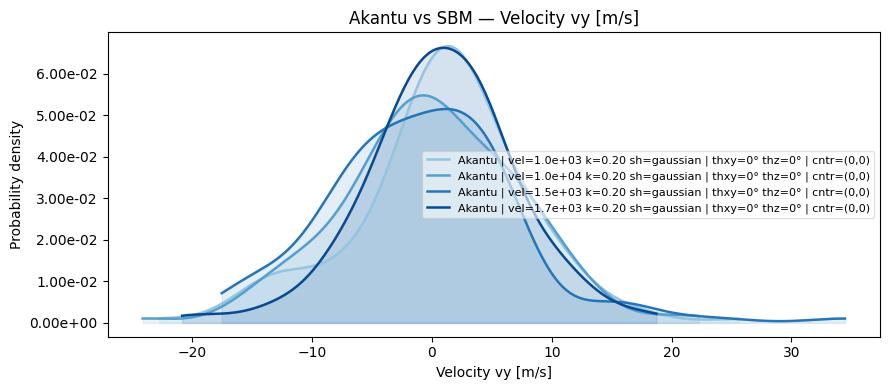

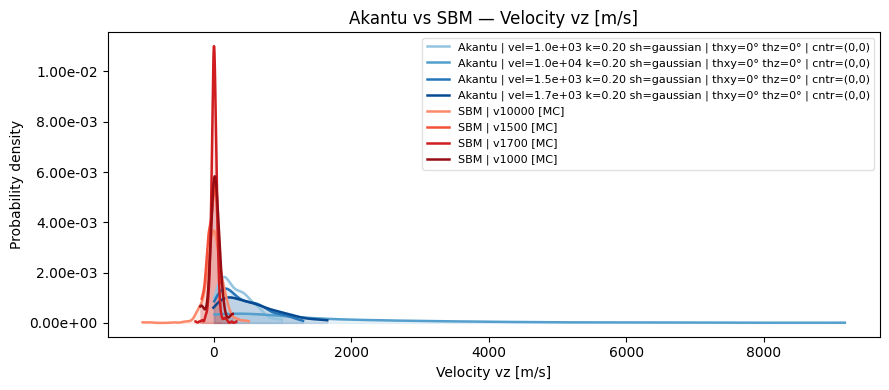

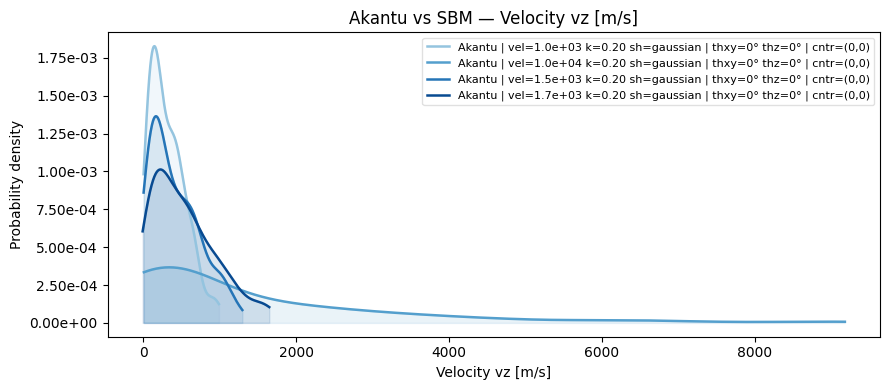

In [12]:
PLOTS = [

    (
        'mass',
        'Fragment mass [kg]',
        True
    ),

    (
        'volume',
        'Fragment volume [m³]',
        True
    ),

    (
        'vmag',
        'Velocity magnitude |v| [m/s]',
        False
    ),

    (
        'vx',
        'Velocity vx [m/s]',
        False
    ),

    (
        'vy',
        'Velocity vy [m/s]',
        False
    ),

    (
        'vz',
        'Velocity vz [m/s]',
        False
    ),
]

for key, xlabel, log_x in PLOTS:

    plot_kde_akantu_vs_sbm(
        akantu_data=fragment_data,
        sbm_data=sbm_fragment_data,
        akantu_selection=AKANTU_SELECTION,
        sbm_selection=SBM_SELECTION_MC,
        key=key,
        xlabel=xlabel,
        log_x=log_x
    )

    plot_kde_akantu_vs_sbm(
        akantu_data=fragment_data,
        sbm_data=sbm_fragment_data,
        akantu_selection=AKANTU_SELECTION,
        sbm_selection=SBM_SELECTION_NOMC,
        key=key,
        xlabel=xlabel,
        log_x=log_x
    )

In [13]:
def scatter_vmag_vs_mass_comparison(
    akantu_data,
    sbm_data,
    akantu_selection,
    sbm_selection,
    figsize=(8, 5),
    alpha=0.5,
    marker_size=18
):

    fig, ax = plt.subplots(figsize=figsize)

    ak_colors = COMPARISON_COLORS['akantu'](
        np.linspace(
            0.4,
            0.9,
            max(len(akantu_selection), 1)
        )
    )

    for label, color in zip(
        akantu_selection,
        ak_colors
    ):

        if label not in akantu_data:
            continue

        fd = akantu_data[label]

        if len(fd['mass']) == 0:
            continue

        ax.scatter(
            fd['mass'],
            fd['vmag'],
            s=marker_size,
            alpha=alpha,
            color=color,
            linewidths=0,
            label=f'Akantu | {label}'
        )
    sbm_colors = COMPARISON_COLORS['sbm'](
        np.linspace(
            0.4,
            0.9,
            max(len(sbm_selection), 1)
        )
    )

    for label, color in zip(
        sbm_selection,
        sbm_colors
    ):

        if label not in sbm_data:
            continue

        if sbm_data[label] is None:
            continue

        fd = sbm_data[label]

        if len(fd['mass']) == 0:
            continue

        ax.scatter(
            fd['mass'],
            fd['vmag'],
            s=marker_size,
            alpha=alpha,
            color=color,
            linewidths=0,
            label=f'SBM | {label}'
        )

    ax.set_xscale('log')

    ax.set_xlabel('Fragment mass [kg]')
    ax.set_ylabel('Velocity magnitude |v| [m/s]')

    ax.set_title(
        'Akantu vs SBM — |v| vs mass'
    )

    ax.legend(
        fontsize=8,
        framealpha=0.6
    )

    plt.tight_layout()
    plt.show()

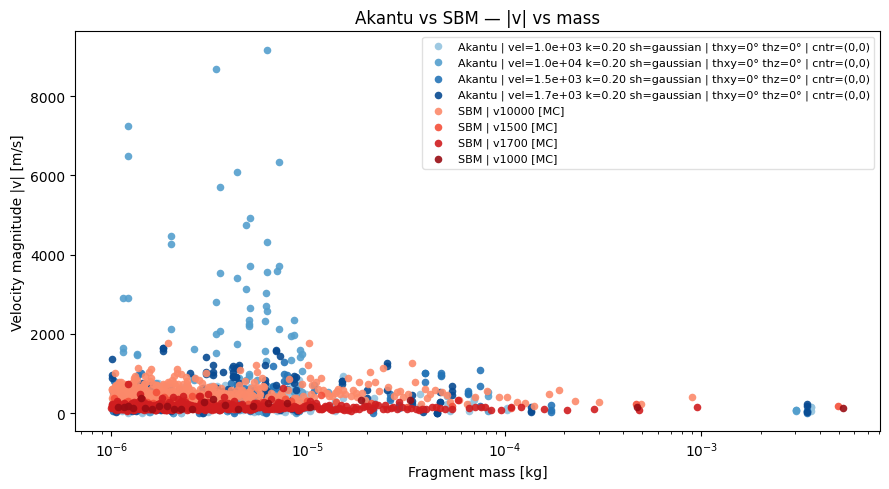

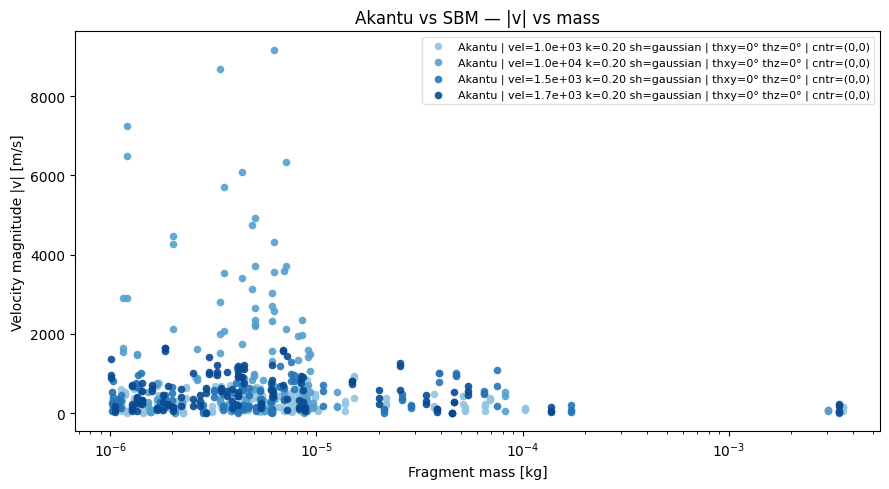

In [14]:
scatter_vmag_vs_mass_comparison(
    akantu_data=fragment_data,
    sbm_data=sbm_fragment_data,
    akantu_selection=AKANTU_SELECTION,
    sbm_selection=SBM_SELECTION_MC,
    figsize=(9, 5),
    alpha=0.9,
    marker_size=30
)

scatter_vmag_vs_mass_comparison(
    akantu_data=fragment_data,
    sbm_data=sbm_fragment_data,
    akantu_selection=AKANTU_SELECTION,
    sbm_selection=SBM_SELECTION_NOMC,
    figsize=(9, 5),
    alpha=0.9,
    marker_size=30
)

In [15]:
def scatter_vmag_vs_volume_comparison(
    akantu_data,
    sbm_data,
    akantu_selection,
    sbm_selection,
    figsize=(8, 5),
    alpha=0.9,
    marker_size=30
):

    fig, ax = plt.subplots(figsize=figsize)

    ak_colors = COMPARISON_COLORS['akantu'](
        np.linspace(
            0.4,
            0.9,
            max(len(akantu_selection), 1)
        )
    )

    for label, color in zip(
        akantu_selection,
        ak_colors
    ):

        fd = akantu_data[label]

        ax.scatter(
            fd['volume'],
            fd['vmag'],
            s=marker_size,
            alpha=alpha,
            color=color,
            linewidths=0,
            label=f'Akantu | {label}'
        )

    sbm_colors = COMPARISON_COLORS['sbm'](
        np.linspace(
            0.4,
            0.9,
            max(len(sbm_selection), 1)
        )
    )

    for label, color in zip(
        sbm_selection,
        sbm_colors
    ):

        fd = sbm_data[label]

        ax.scatter(
            fd['volume'],
            fd['vmag'],
            s=marker_size,
            alpha=alpha,
            color=color,
            linewidths=0,
            label=f'SBM | {label}'
        )

    ax.set_xscale('log')

    ax.set_xlabel(
        'Fragment volume [m³]'
    )

    ax.set_ylabel(
        'Velocity magnitude |v| [m/s]'
    )

    ax.set_title(
        'Akantu vs SBM — |v| vs volume'
    )

    ax.legend(
        fontsize=8,
        framealpha=0.6
    )

    plt.tight_layout()
    plt.show()

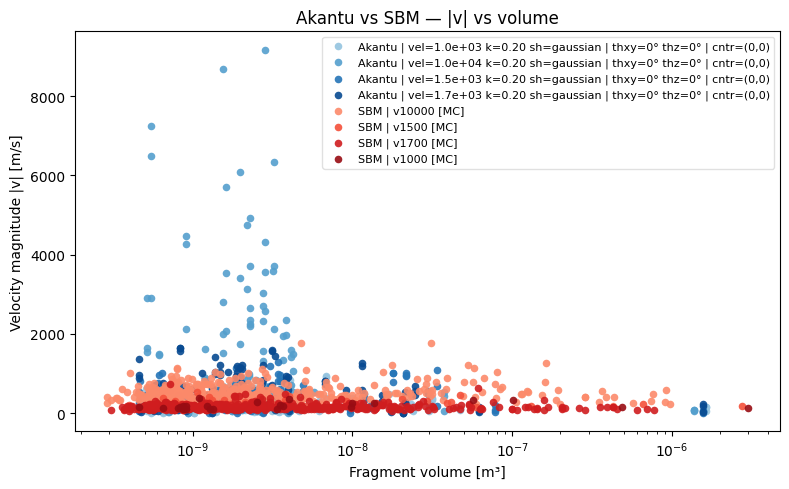

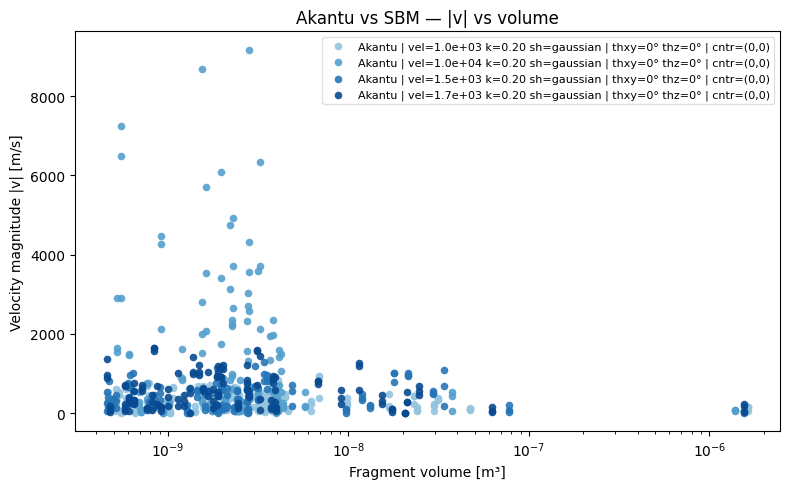

In [16]:
scatter_vmag_vs_volume_comparison(
    akantu_data=fragment_data,
    sbm_data=sbm_fragment_data,
    akantu_selection=AKANTU_SELECTION,
    sbm_selection=SBM_SELECTION_MC,
)

scatter_vmag_vs_volume_comparison(
    akantu_data=fragment_data,
    sbm_data=sbm_fragment_data,
    akantu_selection=AKANTU_SELECTION,
    sbm_selection=SBM_SELECTION_NOMC,
)